In [18]:
import torch
from tumordata import TumorDataset
from model import UNet
import matplotlib.pyplot as plt



torch.Size([3, 572, 572]) torch.Size([1, 388, 388])


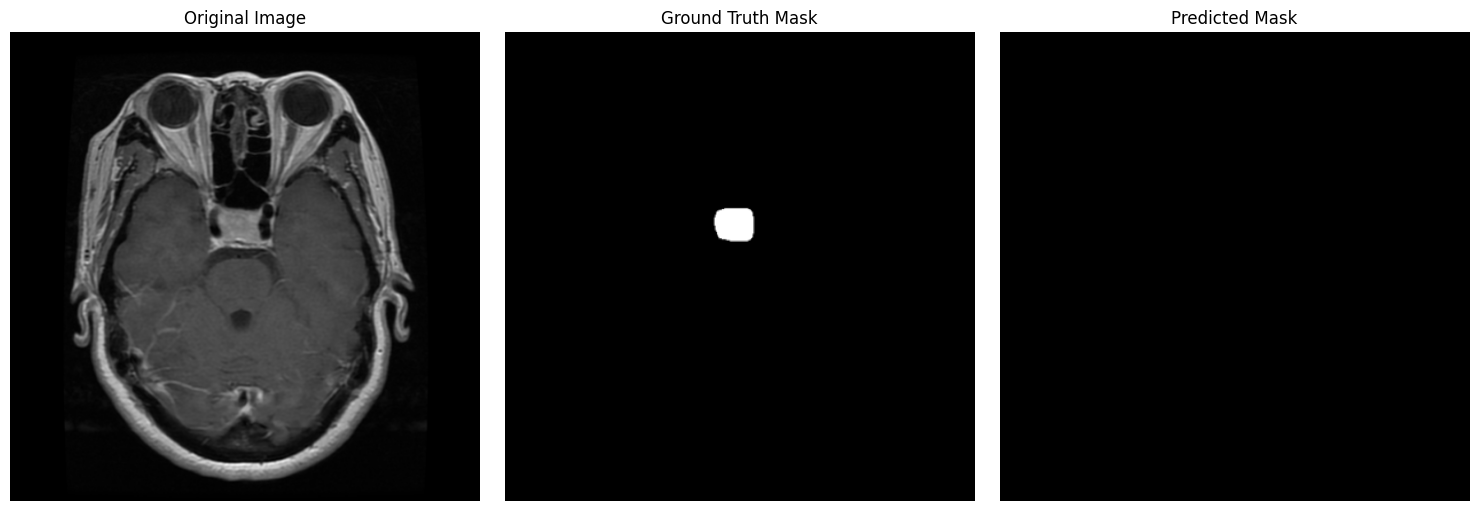

In [36]:
## inferencing 

def inference_img(model_pth, device, dataset, index=0):
    model = UNet(n_classes=1).to(device)
    model.load_state_dict(torch.load(model_pth, map_location=torch.device(device)))
    model.eval()  

    img_tensor, mask_tensor = dataset[index]
    print(img_tensor.size() , mask_tensor.size())
    
    # The image is already a tensor from the dataset, just prepare it for model
    img = img_tensor.unsqueeze(0).float().to(device)  # Add batch dimension
    
    with torch.no_grad():
        pred_mask = model(img)
    
    # Process the prediction
    pred_mask = torch.sigmoid(pred_mask)  
    pred_mask = pred_mask.squeeze(0).cpu()  
    pred_mask = (pred_mask > 0.5).float()
    
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy() 
    pred_mask_np = pred_mask.squeeze().numpy()  
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img_np)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    # Ground truth mask (if available)
    if mask_tensor is not None:
        mask_np = mask_tensor.squeeze().cpu().numpy()
        axes[1].imshow(mask_np, cmap='gray')
        axes[1].set_title('Ground Truth Mask')
        axes[1].axis('off')
    
    # Predicted mask
    axes[2].imshow(pred_mask_np, cmap='gray')
    axes[2].set_title('Predicted Mask')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# # Usage
device = "cuda" if torch.cuda.is_available() else "cpu"
model_path = "unet2.pth"
datapath = "dataset\\train"
dataset = TumorDataset(datapath,is_train=False) 
inference_img(model_path, device, dataset, index=6)
